In [ ]:
import os
import json
import time
import re
import string
import collections
from collections import Counter, defaultdict
from datetime import datetime
import pandas as pd
import numpy as np
from tqdm import tqdm

import torch
from torch.utils.data import DataLoader, Subset

from datasets import Dataset
from transformers import (
    AutoTokenizer,
    AutoModelForQuestionAnswering,
    DebertaV2ForQuestionAnswering,
    get_linear_schedule_with_warmup
)
from torch.optim import AdamW
from safetensors import safe_open

from sklearn.metrics import (
    f1_score,
    classification_report,
    confusion_matrix
)
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

import seaborn as sns
import matplotlib.pyplot as plt

from sentence_transformers import SentenceTransformer

from groq import Groq

In [2]:
import json
import pandas as pd
import numpy as np
from collections import Counter
import os

def squad2_to_df(path: str) -> pd.DataFrame:
    with open(path, "r", encoding="utf-8") as f:
        squad = json.load(f)

    rows = []
    for article in squad["data"]:
        title = article["title"]
        for para_i, para in enumerate(article["paragraphs"]):
            context = para["context"]
            paragraph_id = f"{title}__{para_i}"

            for qa in para["qas"]:
                qid = qa["id"]
                question = qa["question"]
                is_impossible = qa.get("is_impossible", False)
                can_answer = "yes" if not is_impossible else "no"

                if can_answer == "yes" and len(qa.get("answers", [])) > 0:
                    answer_text  = qa["answers"][0]["text"]
                    answer_start = qa["answers"][0]["answer_start"]
                else:
                    answer_text  = "NO_ANSWER"
                    answer_start = -1

                rows.append({
                    "id":           qid,
                    "title":        title,
                    "paragraph_id": paragraph_id,
                    "context":      context,
                    "question":     question,
                    "can_answer":   can_answer,
                    "answer_text":  answer_text,
                    "answer_start": answer_start
                })

    return pd.DataFrame(rows)



train_df = squad2_to_df(os.path.expanduser("train_sampled.json")) # CAMBIAREEEE
val_df   = squad2_to_df(os.path.expanduser("val_sampled.json"))
test_df  = squad2_to_df(os.path.expanduser("test_sampled.json"))


print("Train shape:", train_df.shape)
print("Val shape:  ", val_df.shape)
print("Test shape: ", test_df.shape)

Train shape: (70807, 8)
Val shape:   (8913, 8)
Test shape:  (8990, 8)


## 1) Tokenisation

This block converts raw text DataFrames into tokenized inputs suitable for DeBERTa question answering. Since contexts can be longer than the model's maximum input length (384 tokens), each example is split into overlapping chunks using a sliding window (stride=128). For each chunk, the answer's start and end token positions are computed using character-level offset mappings. Unanswerable questions are assigned start=0 and end=0 (the [CLS] token position).

### a) SentencePiece Tokenizer

DeBERTa uses a **SentencePiece tokenizer**, which splits text into subword units rather than whole words. This allows the model to handle any word, even ones never seen during pre-training, by breaking them into smaller known pieces. Instead of treating each word as a single unit, SentencePiece splits words into subword tokens — the `##` prefix indicates that a token is a continuation of the previous one:

- `"playing"` → `["play", "##ing"]`
- `"unbelievable"` → `["un", "##believe", "##able"]`
- `"Eiffel"` → `["Ei", "##ff", "##el"]`

DeBERTa v3 has a vocabulary of ~128,000 tokens, covering subwords from many languages. Each token is mapped to a unique integer ID (`input_ids`) that the model uses as input.

**Special tokens** structure the input:
- `[CLS]` — classification token, always at position 0. For unanswerable questions, the model points start and end predictions here.
- `[SEP]` — separator between question and context.
- `[PAD]` — padding tokens to reach `MAX_LENGTH=384`.

### b) Offset Mapping

For question answering, we need to map token positions back to character positions in the original text. This is why we use `return_offsets_mapping=True`. Each token gets a `(start_char, end_char)` pair indicating its position in the original string:

```
Text:    "Gustave Eiffel"
Tokens:  ["Gust", "##ave", " Ei", "##ff", "##el"]
Offsets: [(0,4),  (4,7),  (8,10), (10,12), (12,14)]
```

This mapping is essential for converting the model's token-level predictions (start token, end token) back into the actual answer text from the original context.

`sequence_ids()` returns a list indicating which part of the input each token belongs to:
- `None` → special token (`[CLS]`, `[SEP]`, `[PAD]`)
- `0` → question token
- `1` → context token

### c) Sliding Window (doc_stride)

Contexts can be longer than `MAX_LENGTH=384` tokens. To handle this, the tokenizer splits each example into overlapping chunks using a sliding window with `stride=128`:

```
Chunk 1: tokens   0 → 383
Chunk 2: tokens 256 → 383+256
Chunk 3: tokens 512 → 383+512
```

Each chunk overlaps the previous one by 128 tokens, ensuring that answers near chunk boundaries are not missed. This is why the number of tokenized chunks can be greater than the number of original examples.


In [40]:
from transformers import AutoTokenizer
from datasets import Dataset

MODEL_NAME = "microsoft/deberta-v3-base"
MAX_LENGTH = 384 # maximum number of tokens per chunk
DOC_STRIDE = 128 # overlap between consecutive chunks

# Load the DeBERTa tokenizer
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

def tokenize_df(df):
    # Extract raw lists from the DataFrame
    questions   = df["question"].tolist()
    contexts    = df["context"].tolist()
    answers     = df["answer_text"].tolist()  # character-level start positions
    starts      = df["answer_start"].tolist()
    answerables = (df["can_answer"] == "yes").astype(int).tolist()

    # Tokenize question-context pairs with sliding window chunking
    tokenized = tokenizer(
        questions,
        contexts,
        max_length=MAX_LENGTH,
        truncation="only_second",         # only truncate the context, never the question
        stride=DOC_STRIDE,                # overlap of 128 tokens between chunks
        return_overflowing_tokens=True,   # return multiple chunks per example if needed
        return_offsets_mapping=True,      # return char-level offsets for each token
        padding="max_length",             # pad all chunks to MAX_LENGTH
    )

    # Maps each chunk back to its original example index
    sample_map     = tokenized.pop("overflow_to_sample_mapping")
    # Character-level start/end positions for each token in each chunk
    offset_mapping = tokenized.pop("offset_mapping")

    start_positions   = []
    end_positions     = []
    final_answerables = []

    for i, offsets in enumerate(offset_mapping):
        # Get the original example this chunk belongs to
        sample_idx = sample_map[i]
        answerable = answerables[sample_idx]
        final_answerables.append(answerable)

        # Unanswerable: point start and end to [CLS] token (position 0)
        if not answerable:
            start_positions.append(0)
            end_positions.append(0)
            continue

        answer_start = starts[sample_idx]
        answer_text  = answers[sample_idx]

        # Treat missing answers as unanswerable
        if answer_text == "NO_ANSWER" or answer_start == -1:
            start_positions.append(0)
            end_positions.append(0)
            continue

        answer_end   = answer_start + len(answer_text) # Compute answer end character position
        sequence_ids = tokenized.sequence_ids(i) # sequence_ids: 0 = question tokens,
                                                 # 1 = context tokens, None = special tokens

        # Find the first and last context token positions in this chunk
        ctx_start = next(j for j, s in enumerate(sequence_ids) if s == 1)
        ctx_end   = len(sequence_ids) - 1
        while sequence_ids[ctx_end] != 1:
            ctx_end -= 1

        # If the answer falls outside this chunk, mark as unanswerable
        if offsets[ctx_start][0] > answer_start or offsets[ctx_end][1] < answer_end:
            start_positions.append(0)
            end_positions.append(0)
            continue

        # Find the start token: advance until we pass the answer start character
        start = ctx_start
        while start <= ctx_end and offsets[start][0] <= answer_start:
            start += 1
        start_positions.append(start - 1) # step back one to land on answer start

        # Find the end token: retreat until we pass the answer end character
        end = ctx_end
        while end >= ctx_start and offsets[end][1] >= answer_end:
            end -= 1
        end_positions.append(end + 1) # step forward one to land on answer end

    # Add computed labels back to the tokenized output
    tokenized["start_positions"] = start_positions
    tokenized["end_positions"]   = end_positions
    tokenized["answerable"]      = final_answerables
    tokenized["samplem map"]     = sample_map
    return tokenized

# Tokenize all three splits
print("Tokenizing train...")
train_tok = tokenize_df(train_df)
print("Tokenizing val...")
val_tok   = tokenize_df(val_df)
print("Tokenizing test...")
test_tok  = tokenize_df(test_df)

print(f"Train chunks: {len(train_tok['input_ids'])}")
print(f"Val chunks:   {len(val_tok['input_ids'])}")
print(f"Test chunks:  {len(test_tok['input_ids'])}")

Tokenizing train...
Tokenizing val...
Tokenizing test...
Train chunks: 71433
Val chunks:   8997
Test chunks:  9038


### d) HuggingFace Dataset Objects

After tokenization, the raw Python dictionaries are converted into HuggingFace Dataset objects. This format provides built-in support for batching, shuffling, and efficient iteration during training and evaluation. Each dataset is then configured to return PyTorch tensors for the five columns required by the model:

- **`input_ids`** — token IDs for each chunk, representing the question and context as a sequence of integers from the DeBERTa vocabulary
- **`attention_mask`** — binary mask with 1 for real tokens and 0 for padding tokens, telling the model which positions to attend to
- **`token_type_ids`** — segment IDs indicating whether each token belongs to the question (0) or the context (1)
- **`start_positions`** — token index of the answer start, set to 0 for unanswerable questions
- **`end_positions`** — token index of the answer end, set to 0 for unanswerable questions

> Note: the number of chunks in each split can be greater than the original number of examples, since long contexts are split into multiple overlapping chunks by the sliding window tokenization.


In [42]:
# Convert the tokenized dictionaries into HuggingFace Dataset objects.
# This makes it easy to batch, shuffle, and iterate over the data during training.
train_dataset = Dataset.from_dict(train_tok)
val_dataset   = Dataset.from_dict(val_tok)
test_dataset  = Dataset.from_dict(test_tok)

# Define the columns that will be converted to PyTorch tensors.
cols = ["input_ids", "attention_mask", "token_type_ids", "start_positions", "end_positions"]

# Set the format to PyTorch tensors for the specified columns.
# Other columns (e.g. "answerable") remain accessible but are not converted.
train_dataset.set_format(type="torch", columns=cols)
val_dataset.set_format(type="torch",   columns=cols)
test_dataset.set_format(type="torch",  columns=cols)

print("Train dataset:", len(train_dataset))
print("Val dataset:  ", len(val_dataset))
print("Test dataset: ", len(test_dataset))

Train dataset: 71433
Val dataset:   8997
Test dataset:  9038


## 2) Model Training and Validation Performance

The training procedure was carried out for a maximum of **3 epochs** using the **DeBERTa-v3-base Question Answering model**. The optimisation was performed using **AdamW** with a learning rate of **4e-5**, a **weight decay of 0.01**, and a **linear learning rate scheduler with 20% warm-up steps**. Gradient clipping with a norm of **1.0** was applied to stabilise training.

**Key design decisions:**

- **AdamW (`lr=4e-5`, `weight_decay=0.01`)** — standard choice for transformer fine-tuning. The learning rate of 4e-5 is in the range recommended by the DeBERTa paper for SQuAD-style tasks. Weight decay prevents overfitting on the relatively small fine-tuning dataset.
- **Linear scheduler with 20% warm-up** — gradually increases the learning rate from 0 to 4e-5 during the first 20% of training steps, then linearly decays to 0. Warm-up prevents large gradient updates in the first batches when the model parameters are still far from their optimal fine-tuned values.
- **Early stopping (patience=2)** — training stops if validation loss does not improve for 2 consecutive epochs. The best checkpoint (lowest validation loss) is saved and used for final evaluation.

**Monitoring during training:**

- **Training and validation loss** — used to evaluate convergence and detect overfitting
- **Macro F1 score** on the answerability classification task — the answerability prediction is derived from the predicted start token: the prediction is considered *answerable* when the predicted start position differs from the `[CLS]` token

This monitoring strategy allows tracking whether the model is learning meaningful span representations (through loss reduction) and correctly distinguishing answerable and unanswerable questions (through the macro F1 score).


In [20]:

EPOCHS     = 3
BATCH_SIZE = 32
LR         = 4e-5
SAVE_PATH  = "/workspace/v2/deberta_squad_finetuned" #### INSERIRE PATH !!!!!!!!!!!!!!!

device = torch.device("cuda") if torch.cuda.is_available() else torch.device("cpu")


model = DebertaV2ForQuestionAnswering.from_pretrained(MODEL_NAME, torch_dtype=torch.float32)
model.to(device)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE)

optimizer   = AdamW(model.parameters(), lr=LR, weight_decay=0.01)
total_steps = len(train_loader) * EPOCHS
scheduler   = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=int(0.2 * total_steps),
    num_training_steps=total_steps
)

best_val_loss = float("inf")
patience      = 0
MAX_PATIENCE  = 2

for epoch in range(EPOCHS):
    model.train()
    total_loss  = 0
    step_preds  = []
    step_labels = []

    for step, batch in enumerate(train_loader):
        batch   = {k: v.to(device) for k, v in batch.items()}
        outputs = model(**batch)
        loss    = outputs.loss

        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        scheduler.step()
        optimizer.zero_grad()

        with torch.no_grad():
            pred_starts = outputs.start_logits.argmax(dim=-1)
            preds  = (pred_starts != 0).long().cpu().tolist()
            labels = (batch["start_positions"] != 0).long().cpu().tolist()
            step_preds.extend(preds)
            step_labels.extend(labels)

        total_loss += loss.item()

        if step % 50 == 0 and step > 0:
            f1 = f1_score(step_labels, step_preds, average="macro", zero_division=0)
            print(f"Epoch {epoch+1} | Step {step}/{len(train_loader)} | Loss: {loss.item():.4f} | F1: {f1:.4f}")
            step_preds  = []
            step_labels = []

    avg_train_loss = total_loss / len(train_loader)

    # Validation
    model.eval()
    val_loss   = 0
    val_preds  = []
    val_labels = []

    with torch.no_grad():
        for batch in val_loader:
            batch   = {k: v.to(device) for k, v in batch.items()}
            outputs = model(**batch)
            val_loss += outputs.loss.item()

            pred_starts = outputs.start_logits.argmax(dim=-1)
            preds  = (pred_starts != 0).long().cpu().tolist()
            labels = (batch["start_positions"] != 0).long().cpu().tolist()
            val_preds.extend(preds)
            val_labels.extend(labels)

    avg_val_loss = val_loss / len(val_loader)
    val_f1       = f1_score(val_labels, val_preds, average="macro", zero_division=0)

    print(f"\n=== Epoch {epoch+1} | Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f} | Val F1: {val_f1:.4f} ===\n")

    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        patience      = 0
        model.save_pretrained(SAVE_PATH)
        tokenizer.save_pretrained(SAVE_PATH)
        print(f"Saved model (val loss: {best_val_loss:.4f})\n")
    else:
        patience += 1
        print(f"No improvement. Patience: {patience}/{MAX_PATIENCE}\n")
        if patience >= MAX_PATIENCE:
            print("Early stopping.")
            break

Loading weights:   0%|          | 0/198 [00:00<?, ?it/s]

DebertaV2ForQuestionAnswering LOAD REPORT from: microsoft/deberta-v3-base
Key                                     | Status     | 
----------------------------------------+------------+-
mask_predictions.dense.weight           | UNEXPECTED | 
mask_predictions.dense.bias             | UNEXPECTED | 
mask_predictions.classifier.weight      | UNEXPECTED | 
lm_predictions.lm_head.LayerNorm.bias   | UNEXPECTED | 
mask_predictions.classifier.bias        | UNEXPECTED | 
lm_predictions.lm_head.LayerNorm.weight | UNEXPECTED | 
mask_predictions.LayerNorm.bias         | UNEXPECTED | 
mask_predictions.LayerNorm.weight       | UNEXPECTED | 
lm_predictions.lm_head.dense.weight     | UNEXPECTED | 
lm_predictions.lm_head.dense.bias       | UNEXPECTED | 
lm_predictions.lm_head.bias             | UNEXPECTED | 
qa_outputs.weight                       | MISSING    | 
qa_outputs.bias                         | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; no

Epoch 1 | Step 50/2233 | Loss: 5.1587 | F1: 0.3925
Epoch 1 | Step 100/2233 | Loss: 4.0251 | F1: 0.5091
Epoch 1 | Step 150/2233 | Loss: 3.2044 | F1: 0.3993
Epoch 1 | Step 200/2233 | Loss: 3.6340 | F1: 0.3325
Epoch 1 | Step 250/2233 | Loss: 3.0292 | F1: 0.3316
Epoch 1 | Step 300/2233 | Loss: 2.6207 | F1: 0.3494
Epoch 1 | Step 350/2233 | Loss: 2.5543 | F1: 0.4330
Epoch 1 | Step 400/2233 | Loss: 1.9712 | F1: 0.4531
Epoch 1 | Step 450/2233 | Loss: 1.1305 | F1: 0.5346
Epoch 1 | Step 500/2233 | Loss: 1.8200 | F1: 0.5415
Epoch 1 | Step 550/2233 | Loss: 1.6589 | F1: 0.5806
Epoch 1 | Step 600/2233 | Loss: 1.2935 | F1: 0.6305
Epoch 1 | Step 650/2233 | Loss: 1.8893 | F1: 0.6352
Epoch 1 | Step 700/2233 | Loss: 1.2234 | F1: 0.6673
Epoch 1 | Step 750/2233 | Loss: 1.4707 | F1: 0.7017
Epoch 1 | Step 800/2233 | Loss: 1.2523 | F1: 0.7084
Epoch 1 | Step 850/2233 | Loss: 1.1422 | F1: 0.7586
Epoch 1 | Step 900/2233 | Loss: 1.4647 | F1: 0.7339
Epoch 1 | Step 950/2233 | Loss: 1.0300 | F1: 0.7395
Epoch 1 | Ste

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Saved model (val loss: 0.7764)

Epoch 2 | Step 50/2233 | Loss: 0.4953 | F1: 0.8886
Epoch 2 | Step 100/2233 | Loss: 0.8146 | F1: 0.8735
Epoch 2 | Step 150/2233 | Loss: 0.7001 | F1: 0.8869
Epoch 2 | Step 200/2233 | Loss: 1.4711 | F1: 0.8793
Epoch 2 | Step 250/2233 | Loss: 0.7919 | F1: 0.8847
Epoch 2 | Step 300/2233 | Loss: 0.6886 | F1: 0.8797
Epoch 2 | Step 350/2233 | Loss: 1.0286 | F1: 0.8744
Epoch 2 | Step 400/2233 | Loss: 0.7753 | F1: 0.8774
Epoch 2 | Step 450/2233 | Loss: 0.7176 | F1: 0.8908
Epoch 2 | Step 500/2233 | Loss: 0.7391 | F1: 0.8866
Epoch 2 | Step 550/2233 | Loss: 0.6812 | F1: 0.8814
Epoch 2 | Step 600/2233 | Loss: 0.6671 | F1: 0.8818
Epoch 2 | Step 650/2233 | Loss: 0.6038 | F1: 0.8912
Epoch 2 | Step 700/2233 | Loss: 0.5221 | F1: 0.8957
Epoch 2 | Step 750/2233 | Loss: 0.8672 | F1: 0.8978
Epoch 2 | Step 800/2233 | Loss: 0.6176 | F1: 0.8975
Epoch 2 | Step 850/2233 | Loss: 0.2449 | F1: 0.9078
Epoch 2 | Step 900/2233 | Loss: 0.5133 | F1: 0.9023
Epoch 2 | Step 950/2233 | Loss: 0

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Saved model (val loss: 0.6675)

Epoch 3 | Step 50/2233 | Loss: 0.6581 | F1: 0.9417
Epoch 3 | Step 100/2233 | Loss: 0.3609 | F1: 0.9393
Epoch 3 | Step 150/2233 | Loss: 0.3754 | F1: 0.9437
Epoch 3 | Step 200/2233 | Loss: 0.4480 | F1: 0.9466
Epoch 3 | Step 250/2233 | Loss: 0.4888 | F1: 0.9529
Epoch 3 | Step 300/2233 | Loss: 0.5210 | F1: 0.9492
Epoch 3 | Step 350/2233 | Loss: 0.4271 | F1: 0.9551
Epoch 3 | Step 400/2233 | Loss: 0.5392 | F1: 0.9447
Epoch 3 | Step 450/2233 | Loss: 0.5271 | F1: 0.9581
Epoch 3 | Step 500/2233 | Loss: 0.3194 | F1: 0.9538
Epoch 3 | Step 550/2233 | Loss: 0.3500 | F1: 0.9511
Epoch 3 | Step 600/2233 | Loss: 0.4018 | F1: 0.9447
Epoch 3 | Step 650/2233 | Loss: 0.7332 | F1: 0.9490
Epoch 3 | Step 700/2233 | Loss: 0.2572 | F1: 0.9461
Epoch 3 | Step 750/2233 | Loss: 0.5495 | F1: 0.9524
Epoch 3 | Step 800/2233 | Loss: 0.5838 | F1: 0.9485
Epoch 3 | Step 850/2233 | Loss: 0.3925 | F1: 0.9466
Epoch 3 | Step 900/2233 | Loss: 0.4760 | F1: 0.9429
Epoch 3 | Step 950/2233 | Loss: 0

## 3) Model Weights

The trained model weights are available on our [shared Google Drive](https://drive.google.com/drive/u/1/folders/1qrieC-mHhRIrC2OecUTZwMuXtSQfHDb3). To skip the full training pipeline and load the best model directly, run the cell below:


### Load best model


In [22]:
MODEL_PATH = "v2/deberta_squad_finetuned"  #### INSERIRE PATH !!!!!!!!!!!!!!!

device = torch.device(
    "mps" if torch.backends.mps.is_available() else "cpu"
)

model = AutoModelForQuestionAnswering.from_pretrained(MODEL_PATH)
tokenizer = AutoTokenizer.from_pretrained(MODEL_PATH)

model.to(device)
model.eval()

print("Model loaded successfully")

Loading weights: 100%|██████████| 200/200 [00:00<00:00, 6417.68it/s]


Model loaded successfully


In [25]:
import torch
import collections
import string
import re
from torch.utils.data import DataLoader
from sklearn.metrics import classification_report

device = torch.device("mps") if torch.mps.is_available() else torch.device("cpu") # cuda
model.eval()

test_loader = DataLoader(test_dataset, batch_size=8)

all_preds        = []
all_labels       = []
all_start_logits = []
all_end_logits   = []
all_start_labels = []
all_end_labels   = []

with torch.no_grad():
    for batch in test_loader:
        batch   = {k: v.to(device) for k, v in batch.items()}
        outputs = model(**batch)

        pred_starts = outputs.start_logits.argmax(dim=-1)
        preds  = (pred_starts != 0).long().cpu().tolist()
        labels = (batch["start_positions"] != 0).long().cpu().tolist()
        all_preds.extend(preds)
        all_labels.extend(labels)

        all_start_logits.extend(outputs.start_logits.cpu().tolist())
        all_end_logits.extend(outputs.end_logits.cpu().tolist())
        all_start_labels.extend(batch["start_positions"].cpu().tolist())
        all_end_labels.extend(batch["end_positions"].cpu().tolist())

print("=== Answerability Classification ===")
print(classification_report(all_labels, all_preds, target_names=["unanswerable", "answerable"]))

def normalize_answer(s):
    s = s.lower()
    s = re.sub(r'\b(a|an|the)\b', ' ', s)
    s = ''.join(ch for ch in s if ch not in string.punctuation)
    s = ' '.join(s.split())
    return s

def get_tokens(s):
    return normalize_answer(s).split()

def compute_exact(pred, gold):
    return int(normalize_answer(pred) == normalize_answer(gold))

def compute_f1(pred, gold):
    pred_tokens = get_tokens(pred)
    gold_tokens = get_tokens(gold)
    common      = collections.Counter(pred_tokens) & collections.Counter(gold_tokens)
    num_same    = sum(common.values())
    if num_same == 0:
        return 0.0
    precision = num_same / len(pred_tokens)
    recall    = num_same / len(gold_tokens)
    return (2 * precision * recall) / (precision + recall)

# EM, F1 just on answerable examples — no sample_map
em_scores = []
f1_scores = []

for i in range(len(all_start_logits)):
    start_true = all_start_labels[i]
    end_true   = all_end_labels[i]

    # Skip unanswerable
    if start_true == 0:
        continue

    start_logits = torch.tensor(all_start_logits[i])
    end_logits   = torch.tensor(all_end_logits[i])

    null_score = start_logits[0] + end_logits[0]
    best_start = int(start_logits[1:].argmax()) + 1
    best_end   = int(end_logits[1:].argmax()) + 1
    best_score = start_logits[best_start] + end_logits[best_end]

    if null_score > best_score:
        pred_text = ""
    else:
        if best_end < best_start:
            best_end = best_start
        input_ids = test_dataset[i]["input_ids"].tolist()
        pred_text = tokenizer.decode(input_ids[best_start:best_end + 1], skip_special_tokens=True)

    input_ids = test_dataset[i]["input_ids"].tolist()
    gold_text = tokenizer.decode(input_ids[start_true:end_true + 1], skip_special_tokens=True)

    em_scores.append(compute_exact(pred_text, gold_text))
    f1_scores.append(compute_f1(pred_text, gold_text))

print(f"\n=== QA Span Metrics (just answerable) ===")
print(f"Exact Match (EM): {sum(em_scores)/len(em_scores):.4f}")
print(f"F1 Score:         {sum(f1_scores)/len(f1_scores):.4f}")
print(f"Support:  {len(em_scores)}")

=== Answerability Classification ===
              precision    recall  f1-score   support

unanswerable       0.91      0.89      0.90      3798
  answerable       0.92      0.93      0.93      5240

    accuracy                           0.92      9038
   macro avg       0.91      0.91      0.91      9038
weighted avg       0.92      0.92      0.92      9038


=== QA Span Metrics (just answerable) ===
Exact Match (EM): 0.6767
F1 Score:         0.8006
Support:  5240


=== Confusion Matrix ===
[[3380  418]
 [ 348 4892]]


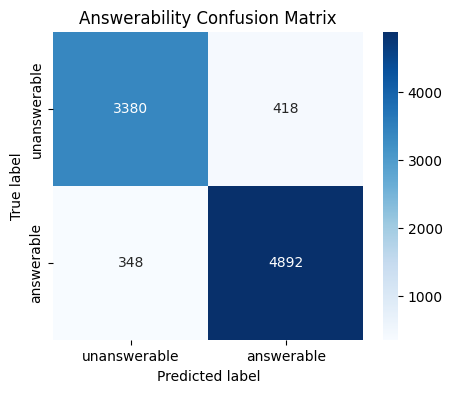

In [26]:
# Confusion matrix
cm = confusion_matrix(all_labels, all_preds)

print("=== Confusion Matrix ===")
print(cm)

# Plot
plt.figure(figsize=(5,4))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["unanswerable", "answerable"],
    yticklabels=["unanswerable", "answerable"]
)

plt.xlabel("Predicted label")
plt.ylabel("True label")
plt.title("Answerability Confusion Matrix")
plt.show()

In [27]:
def answer_question(question, context, model, tokenizer, device, max_length=384, doc_stride=128):
    model.eval()

    inputs = tokenizer(
        question,
        context,
        max_length=max_length,
        truncation="only_second",
        stride=doc_stride,
        return_overflowing_tokens=True,
        return_offsets_mapping=True,
        padding="max_length",
        return_tensors="pt"
    )

    offset_mapping = inputs.pop("offset_mapping")
    sample_map     = inputs.pop("overflow_to_sample_mapping")

    inputs = {k: v.to(device) for k, v in inputs.items()}

    with torch.no_grad():
        outputs = model(**inputs)

    best_score  = -float("inf")
    best_answer = ""

    for i in range(len(outputs.start_logits)):
        start_logits = outputs.start_logits[i]
        end_logits   = outputs.end_logits[i]
        offsets      = offset_mapping[i]

        # Null score
        null_score = start_logits[0] + end_logits[0]

        # Best span
        best_start = int(start_logits[1:].argmax()) + 1
        best_end   = int(end_logits[1:].argmax()) + 1
        span_score = start_logits[best_start] + end_logits[best_end]

        if span_score > best_score:
            best_score = span_score.item()

            if null_score > span_score:
                best_answer = "The model cannot answer to this question."
            else:
                if best_end < best_start:
                    best_end = best_start
                start_char = offsets[best_start][0].item()
                end_char   = offsets[best_end][1].item()
                best_answer = context[start_char:end_char]

    return best_answer


# ── Examples ──────────────────────────────────────
context = """
The Eiffel Tower is a wrought-iron lattice tower on the Champ de Mars in Paris, France.
It is named after the engineer Gustave Eiffel, whose company designed and built the tower
from 1887 to 1889. The tower is 330 metres tall and was the tallest man-made structure in
the world for 41 years.
"""

# Question with answer
question1 = "How tall is the Eiffel Tower?"
answer1   = answer_question(question1, context, model, tokenizer, device)
print(f"Q: {question1}")
print(f"A: {answer1}\n")

# Question without answer
question2 = "Who is the president of France?"
answer2   = answer_question(question2, context, model, tokenizer, device)
print(f"Q: {question2}")
print(f"A: {answer2}\n")

# Question about a fact present in the context
question3 = "Who designed the Eiffel Tower?"
answer3   = answer_question(question3, context, model, tokenizer, device)
print(f"Q: {question3}")
print(f"A: {answer3}\n")

# Question about a fact not present in the context
question4 = "When was the Eiffel Tower painted red?"
answer4   = answer_question(question4, context, model, tokenizer, device)
print(f"Q: {question4}")
print(f"A: {answer4}\n")

Q: How tall is the Eiffel Tower?
A:  330 metres tall

Q: Who is the president of France?
A: The model cannot answer to this question.

Q: Who designed the Eiffel Tower?
A:  Gustave Eiffel

Q: When was the Eiffel Tower painted red?
A: The model cannot answer to this question.



## 4) RAG Pipeline

The implemented system follows a **Retrieval-Augmented Generation (RAG)** architecture for **extractive Question Answering (QA)**. The pipeline combines **semantic retrieval, lexical retrieval, and a transformer-based QA model** in order to first retrieve the most relevant contexts and then extract the answer span from them.

### a) Retrieval Stage

The retrieval stage is built using two complementary representations of the documents.

**Dense semantic retrieval:** contexts are converted into dense semantic embeddings using the pretrained model `multi-qa-MiniLM-L6-cos-v1`. This model maps each text into a vector

$$f(\text{text}) \rightarrow \mathbb{R}^{384}$$

such that semantically similar sentences are located close to each other in the embedding space. This allows the system to retrieve contexts that are **semantically related to the question**, even if they do not share the same wording.

**Lexical retrieval (TF-IDF):** a TF–IDF lexical index is constructed. TF–IDF represents documents using weighted word frequencies

$$w_{i,j} = tf_{i,j} \cdot idf_j$$

where

$$idf_j = \log\left(\frac{N}{df_j}\right)$$

so that rare and informative terms receive higher importance. The vectorizer uses **unigrams and bigrams**, which helps capture short phrases such as *national archives* or *military operation* that are often important in QA tasks.

**Hybrid scoring:** the final retrieval score combines semantic and lexical similarity:

$$score = \alpha \cdot s_{\text{semantic}} + (1-\alpha) \cdot s_{\text{lexical}}$$

with $\alpha = 0.7$. This hybrid strategy improves robustness because semantic retrieval captures **meaning and paraphrases**, while lexical retrieval captures **exact keyword matches**.

### b) Reader Stage

Once the most relevant contexts are retrieved, they are passed to the DeBERTa QA model. The input is structured as:

```
[CLS] question [SEP] context [SEP]
```

If the context is too long, it is split using a sliding window with overlap. The model outputs `start_logits` and `end_logits`, and the final answer is obtained by selecting the span that maximises:

$$score(i,j) = start\_logit_i + end\_logit_j$$

Since the system is trained on SQuAD 2.0, it can also detect unanswerable questions: if the score associated with the `[CLS]` token is higher than any candidate span, the model predicts that **no answer is present in the retrieved contexts**.


In [ ]:
# ── 1. Installing the embedding model ──────────────────────────────────

# !pip install sentence-transformers -q
# Sentence Transformers produce dense vector representations (embeddings) for text

# ── 2. Building the context index ────────────
from sentence_transformers import SentenceTransformer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np
import torch
import pandas as pd

all_contexts = [] # original contexts
all_contexts_with_title = [] # contexts enriched with titles

# removing duplicated contexts across train/val/test
seen = set()
for df in [train_df, val_df, test_df]:
    for _, row in df.iterrows():
        ctx   = row["context"]
        title = str(row["title"]).replace("_", " ")
        if ctx not in seen:
            seen.add(ctx)
            all_contexts.append(ctx)
            all_contexts_with_title.append(f"{title}. {ctx}")

print(f"Contexts in the index: {len(all_contexts)}")

# Sentence embeddings with the enriched text (adding title helps the model understand the topic of the context)
print("Loading embedding model...")
embedder = SentenceTransformer("multi-qa-MiniLM-L6-cos-v1")

print("Computing semantic embeddings...")
ctx_embeddings = embedder.encode(
    all_contexts_with_title,
    batch_size=64,
    show_progress_bar=True,
    convert_to_numpy=True
)

# TF-IDF on the enriched text
print("Building TF-IDF index...")
vectorizer   = TfidfVectorizer(max_features=50000, ngram_range=(1, 2))
tfidf_matrix = vectorizer.fit_transform(all_contexts_with_title)

# ── 3. Hybrid Retriever ───────────────────────────────
def retrieve(question, k=10, alpha=0.7):
    # enriched question
    enriched_q = f"question: {question}"

    q_emb      = embedder.encode([enriched_q], convert_to_numpy=True)
    sem_scores = cosine_similarity(q_emb, ctx_embeddings).flatten()

    q_tfidf    = vectorizer.transform([enriched_q])
    lex_scores = cosine_similarity(q_tfidf, tfidf_matrix).flatten()

    sem_scores = (sem_scores - sem_scores.min()) / (sem_scores.max() - sem_scores.min() + 1e-9)
    lex_scores = (lex_scores - lex_scores.min()) / (lex_scores.max() - lex_scores.min() + 1e-9)

    combined = alpha * sem_scores + (1 - alpha) * lex_scores
    top_k    = combined.argsort()[-k:][::-1]
    return [(all_contexts[i], float(combined[i])) for i in top_k]

# ── 4. Pipeline RAG ───────────────────────────────────
def rag(question, model, tokenizer, device, k=5, alpha=0.7, verbose=True): 
    retrieved = retrieve(question, k=k, alpha=alpha)

    if verbose:
        print(f"\n{'='*60}")
        print(f"Question: {question}")
        print(f"{'='*60}")
        print(f"\n Top {k} retrieved contexts:")
        for j, (ctx, score) in enumerate(retrieved):
            print(f"\n  [{j+1}] Score: {score:.4f}")
            print(f"  {ctx}")

    best_answer     = None
    best_context    = None
    best_span_score = -float("inf")

    model.eval()
    for ctx, retrieval_score in retrieved:
        inputs = tokenizer(
            question,
            ctx,
            max_length=384,
            truncation="only_second",
            stride=128,
            return_overflowing_tokens=True,
            return_offsets_mapping=True,
            padding="max_length",
            return_tensors="pt"
        )

        offset_mapping = inputs.pop("offset_mapping")
        inputs.pop("overflow_to_sample_mapping")
        inputs = {k: v.to(device) for k, v in inputs.items()}

        with torch.no_grad():
            outputs = model(**inputs)

        for i in range(len(outputs.start_logits)):
            start_logits = outputs.start_logits[i]
            end_logits   = outputs.end_logits[i]
            offsets      = offset_mapping[i]

            null_score = start_logits[0] + end_logits[0]
            span_start = int(start_logits[1:].argmax()) + 1
            span_end   = int(end_logits[1:].argmax()) + 1
            span_score = start_logits[span_start] + end_logits[span_end]

            if span_score > null_score and span_score > best_span_score:
                best_span_score = span_score.item()
                if span_end < span_start:
                    span_end = span_start
                start_char   = offsets[span_start][0].item()
                end_char     = offsets[span_end][1].item()
                best_answer  = ctx[start_char:end_char]
                best_context = ctx

    if verbose:
        print(f"\n{'='*60}")
        if best_answer:
            print(f"Answer: {best_answer}")
            print(f"\n From the context:\n{best_context}")
        else:
            print(f"No answer found in the retrieved contexts.")
        print(f"{'='*60}\n")

    return best_answer


##### TAGLIARE UN PO' DI ESSEMPIIII!!!!!!!!!!!!!!!!!!!!!!
# ── 5. Test ───────────────────────────────────────────
# National Archives
rag("How did the National Archives make its documents available online?", model, tokenizer, device)
rag("How many digital records does NARA store?",                          model, tokenizer, device)
rag("Which university is near the second National Archives facility?",    model, tokenizer, device)

# Church and State
rag("Why did early immigrants come to America?",                          model, tokenizer, device)
rag("Who was persecuting the Puritans in England?",                       model, tokenizer, device)

# Eritrea
rag("What European country influenced Eritrean cuisine?",                 model, tokenizer, device)
rag("What is the traditional alcoholic drink of Eritrea made from?",      model, tokenizer, device)

# Afghanistan
rag("Where did the Taliban regroup after 2002?",                          model, tokenizer, device)
rag("What military operation took place in southern Afghanistan in 2010?", model, tokenizer, device)

# Charleston
rag("How did Charles Town become wealthy?",                               model, tokenizer, device)
rag("When was the American version of the Spoleto festival created?",     model, tokenizer, device)

# Questions with no answer
rag("What is the price of Bitcoin today?",                                model, tokenizer, device)
rag("Who is the current CEO of Apple?",                                   model, tokenizer, device)


Contexts in the index: 16629
Loading embedding model...


Loading weights: 100%|██████████| 103/103 [00:00<00:00, 9378.95it/s]
BertModel LOAD REPORT from: sentence-transformers/multi-qa-MiniLM-L6-cos-v1
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Computing semantic embeddings...


Batches: 100%|██████████| 260/260 [01:38<00:00,  2.64it/s]


Building TF-IDF index...

Question: How did the National Archives make its documents available online?

 Top 10 retrieved contexts:

  [1] Score: 0.9973
  The National Archives Building, known informally as Archives I, located north of the National Mall on Constitution Avenue in Washington, D.C., opened as its original headquarters in 1935. It holds the original copies of the three main formative documents of the United States and its government: the Declaration of Independence, the Constitution, and the Bill of Rights. It also hosts a copy of the 1297 Magna Carta confirmed by Edward I. These are displayed to the public in the main chamber of the National Archives, which is called the Rotunda for the Charters of Freedom. The National Archives Building also exhibits other important American historical documents such as the Louisiana Purchase Treaty, the Emancipation Proclamation, and collections of photography and other historically and culturally significant American artifacts.

  [2] 

' John Sculley'

### c) RAG Evaluation Metrics


In [ ]:
# ── RAG + DeBERTa Evaluation ──────────────────────────────────────────
# Evaluates the full RAG pipeline on the test set
# For each question: RAG retrieves top-k contexts, DeBERTa predicts the answer
# EM and F1 are computed against the original SQuAD 2.0 gold answers

import torch
import collections
import string
import re
from sklearn.metrics import classification_report


def evaluate_rag_deberta(test_df, model, tokenizer, device, k=20, alpha=0.7):
    """
    For each question in test_df:
      1. RAG retrieves top-k contexts
      2. DeBERTa predicts the answer span from each context
      3. Best answer is selected based on span score
      4. EM and F1 are computed against the gold answer
    """

    em_scores  = []
    f1_scores  = []
    all_preds  = []
    all_labels = []
    predictions_log = []

    model.eval()

    for idx, row in test_df.iterrows():

        question      = row["question"]
        gold_text     = row["answer_text"]
        is_answerable = int(row["answer_start"] != -1)
        all_labels.append(is_answerable)

        retrieved = retrieve(question, k=k, alpha=alpha)

        best_answer      = ""
        best_final_score = -float("inf")

        with torch.no_grad():

            for ctx, retrieval_score in retrieved:

                inputs = tokenizer(
                    question,
                    ctx,
                    max_length=512,
                    truncation="only_second",
                    stride=128,
                    return_overflowing_tokens=True,
                    return_offsets_mapping=True,
                    padding="max_length",
                    return_tensors="pt"
                )

                offset_mapping = inputs.pop("offset_mapping")
                inputs.pop("overflow_to_sample_mapping")

                inputs = {k: v.to(device) for k, v in inputs.items()}

                outputs = model(**inputs)

                for i in range(len(outputs.start_logits)):

                    start_logits = outputs.start_logits[i]
                    end_logits   = outputs.end_logits[i]
                    offsets      = offset_mapping[i]

                    null_score = start_logits[0] + end_logits[0]

                    # ── Correct span search ──────────────────────────
                    best_span_score = -float("inf")
                    best_start = 0
                    best_end   = 0

                    for s in range(1, len(start_logits)):
                        for e in range(s, min(s+30, len(end_logits))):  # max answer length 30
                            score = start_logits[s] + end_logits[e]
                            if score > best_span_score:
                                best_span_score = score
                                best_start = s
                                best_end   = e

                    # ── Combine span score + retrieval score ─────────
                    final_score = best_span_score.item() + 0.1 * retrieval_score

                    if best_span_score > null_score and final_score > best_final_score:

                        best_final_score = final_score

                        start_char = offsets[best_start][0].item()
                        end_char   = offsets[best_end][1].item()

                        best_answer = ctx[start_char:end_char]

        pred_text       = best_answer
        pred_answerable = int(pred_text.strip() != "")
        all_preds.append(pred_answerable)
        predictions_log.append({
            "id": idx,
            "question": question,
            "gold_answer": gold_text,
            "prediction": pred_text,
            "answerable_gold": is_answerable,
            "answerable_pred": pred_answerable
        })

        if is_answerable:
            em_scores.append(compute_exact(pred_text, gold_text))
            f1_scores.append(compute_f1(pred_text, gold_text))

        if (idx + 1) % 100 == 0:
            print(f"Processed {idx+1}/{len(test_df)} examples...")

    print("\n=== Answerability Classification — DeBERTa + RAG ===")
    print(classification_report(all_labels, all_preds,
                                target_names=["unanswerable", "answerable"]))

    print("\n=== QA Span Metrics — DeBERTa + RAG ===")
    print(f"Exact Match (EM): {sum(em_scores)/len(em_scores):.4f}")
    print(f"F1 Score:         {sum(f1_scores)/len(f1_scores):.4f}")
    print(f"Support:          {len(em_scores)}")

    # ── Save predictions ─────────────────────────────

    with open("rag_predictions.json", "w") as f:
        json.dump(predictions_log, f, indent=2)

    df_preds = pd.DataFrame(predictions_log)
    df_preds.to_csv("rag_predictions.csv", index=False)

    print("\nSaved predictions to:")
    print(" - rag_predictions.json")
    print(" - rag_predictions.csv")

    return {
        "em": sum(em_scores)/len(em_scores),
        "f1": sum(f1_scores)/len(f1_scores)
    }

# ── Run ───────────────────────────────────────────────────────────────
results_rag = evaluate_rag_deberta(test_df, model, tokenizer, device, k=20)

# ── Final comparison ──────────────────────────────────────────────────
# Replace with your actual DeBERTa standalone numbers
em_deberta = 0.6767
f1_deberta = 0.8006

print("\n========== FINAL COMPARISON ==========")
print(f"{'Setup':<25} {'EM':>8} {'F1':>8}")
print(f"{'-'*45}")
print(f"{'DeBERTa (gold context)':<25} {em_deberta:>8.4f} {f1_deberta:>8.4f}")
print(f"{'DeBERTa + RAG':<25} {results_rag['em']:>8.4f} {results_rag['f1']:>8.4f}")

    

  Processed 100/8990 examples...
  Processed 200/8990 examples...
  Processed 300/8990 examples...
  Processed 400/8990 examples...
  Processed 500/8990 examples...
  Processed 600/8990 examples...
  Processed 700/8990 examples...
  Processed 800/8990 examples...
  Processed 900/8990 examples...
  Processed 1000/8990 examples...
  Processed 1100/8990 examples...
  Processed 1200/8990 examples...
  Processed 1300/8990 examples...
  Processed 1400/8990 examples...
  Processed 1500/8990 examples...
  Processed 1600/8990 examples...
  Processed 1700/8990 examples...
  Processed 1800/8990 examples...
  Processed 1900/8990 examples...
  Processed 2000/8990 examples...
  Processed 2100/8990 examples...
  Processed 2200/8990 examples...
  Processed 2300/8990 examples...
  Processed 2400/8990 examples...
  Processed 2500/8990 examples...
  Processed 2600/8990 examples...
  Processed 2700/8990 examples...
  Processed 2800/8990 examples...
  Processed 2900/8990 examples...
  Processed 3000/8990 e

### d) Gold Context vs RAG Results

The comparison shows that DeBERTa evaluated with the gold context clearly outperforms the DeBERTa + RAG pipeline, achieving higher Exact Match and F1 scores. This result is expected, since in the gold-context setting the model receives the correct passage directly, while in the RAG setting performance also depends on the retrieval stage. Any retrieval error propagates to the reader and lowers the final score.

In our case, the retriever was limited to a small number of retrieved passages (k=5) for computational reasons, which likely reduced the probability of including the truly relevant context among the candidates. Therefore, the lower performance of the RAG-based system should not be interpreted as evidence that retrieval augmentation is ineffective in general, but rather as a consequence of the limited retrieval depth and the additional complexity of the end-to-end pipeline.


## 5) LLM-Based Verification of Automatic Evaluation Metrics


### a) Automatic Evaluation on Answerable Subset

Before using the LLM, we evaluated the question answering model on a subset of the test set by focusing only on answerable questions, due to the limits of the free API. Specifically, we randomly selected **800 answerable observations** and performed inference with the fine-tuned model using the original question–context pairs.

Since each context could be split into multiple overlapping chunks during tokenization, we first reconstructed the mapping between chunks and original examples, then ran the model on all corresponding chunks and retained, for each question, the answer span with the highest score across them.

After obtaining the final prediction for every sampled example, we compared it with the gold answer and computed the standard Exact Match (EM) and F1 metrics. These scores are therefore calculated only on the selected sample of 800 answerable examples, rather than on the entire test set.

The resulting file contains, for each sampled question: the original context, the reference answer, the predicted answer, and the associated evaluation scores — providing a first benchmark of the model's extractive QA performance under the gold-context setting.


In [44]:
# CONFIGURATION
N_SAMPLE   = 800
BATCH_SIZE = 32
SAVE_PATH  = "./results" ### MODIFICAREEEEEEEEEEEEEEEEEEEEEEEEEE!!!!!!!!!!!!!!!!!!!!!!!!!!!!!
os.makedirs(SAVE_PATH, exist_ok=True)

# STEP 1: sample 800 answerable rows from test_df 
df_answerable = test_df[test_df["y"] == 1]                       # filter only answerable examples
df_sample     = df_answerable.sample(N_SAMPLE, random_state=42)  # randomly sample 800 answerable examples
sampled_idx   = set(df_sample.index.tolist())                    # keep track of original indices of the sampled examples for later mapping

print(f"Answerable in test : {len(df_answerable)}")
print(f"Sample size        : {len(df_sample)}")

# STEP 2: single tokenizer call to get sample_map + offset_mapping for the entire test set (we will subset to our sample later)
print("Computing sample_map and offset_mapping...")
_tok = tokenizer(
    test_df["question"].tolist(),
    test_df["context"].tolist(),
    max_length=MAX_LENGTH,
    truncation="only_second",
    stride=DOC_STRIDE,
    return_overflowing_tokens=True,
    return_offsets_mapping=True,
    padding="max_length",
) 
sample_map    = _tok["overflow_to_sample_mapping"] # maps each chunk to its original example index in test_df
chunk_indices = [
    chunk_i for chunk_i, orig_idx in enumerate(sample_map)
    if orig_idx in sampled_idx
] # indices of chunks that belong to our sampled examples
print(f"Total chunks in sample : {len(chunk_indices)}")

sample_offsets      = [_tok["offset_mapping"][i] for i in chunk_indices] # offset mapping for each chunk in the sample
sample_sequence_ids = [_tok.sequence_ids(i)      for i in chunk_indices] # sequence ids for each chunk in the sample (to identify question vs context tokens)
sample_sample_map   = [sample_map[i]             for i in chunk_indices] # original example index for each chunk in the sample

# STEP 3: DataLoader on the subset 
cols = ["input_ids", "attention_mask", "token_type_ids", "start_positions", "end_positions"]
test_dataset.set_format(type="torch", columns=cols)
sample_loader = DataLoader(Subset(test_dataset, chunk_indices), batch_size=BATCH_SIZE, shuffle=False)

# STEP 4: inference 
all_start_logits = []
all_end_logits   = []

with torch.no_grad():
    for batch in tqdm(sample_loader, desc="Inference"):
        batch   = {k: v.to(device) for k, v in batch.items()}       # move batch to device
        outputs = model(**batch)                                    # forward pass
        all_start_logits.append(outputs.start_logits.cpu().numpy()) # collect start logits
        all_end_logits.append(outputs.end_logits.cpu().numpy())     # collect end logits

all_start_logits = np.concatenate(all_start_logits, axis=0)         # shape: (num_chunks_in_sample, max_length)
all_end_logits   = np.concatenate(all_end_logits,   axis=0)         # shape: (num_chunks_in_sample, max_length)

# STEP 5: extract best answer per example 

# It converts the model's raw outputs into one final answer for each original example.
# Since long contexts are split into multiple overlapping chunks during tokenization, the QA model produces start and end logits for each chunk rather than one direct prediction
# for the whole question-context pair.

# The function `extract_best_answer()` works at the chunk level. It first identifies the token positions that belong only to the context, excluding the question and special tokens.
# Then, instead of checking every possible token span, it selects the top candidate start and end positions according to the logits and evaluates all valid combinations among them.
# Invalid spans are discarded, for example when they fall outside the context or when the end index comes before the start index. For each valid span, the code computes a score as
# the sum of the start and end logits, and the highest-scoring span is converted back into text through the offset mappings. In this way, the function returns the best predicted
# answer for a single chunk together with its score.

def extract_best_answer(context, offsets, sequence_ids, start_logits, end_logits, n_best=20):
    ctx_start = next((j for j, s in enumerate(sequence_ids) if s == 1), None) 
    if ctx_start is None:
        return "", float("-inf") 
    ctx_end = len(sequence_ids) - 1
    while ctx_end >= 0 and sequence_ids[ctx_end] != 1: 
        ctx_end -= 1

    start_indexes = np.argsort(start_logits)[-n_best:][::-1].tolist()
    end_indexes   = np.argsort(end_logits)[-n_best:][::-1].tolist()

    best_answer, best_score = "", float("-inf")
    for s in start_indexes:
        for e in end_indexes:
            if s < ctx_start or e > ctx_end or e < s:
                continue
            if offsets[s] is None or offsets[e] is None:
                continue
            score = start_logits[s] + end_logits[e]
            if score > best_score:
                best_score  = score
                best_answer = context[offsets[s][0]:offsets[e][1]].strip()
    return best_answer, best_score

# This part of the code groups all chunks that come from the same original example.
# This is necessary because one question-context pair may generate multiple chunks after tokenization. For each example, the code applies `extract_best_answer()` to all its chunks
# and keeps only the answer with the highest score across them. The result is therefore a single final prediction for each sampled observation.
chunk_by_example = defaultdict(list)
for local_i, orig_idx in enumerate(sample_sample_map):
    chunk_by_example[orig_idx].append(local_i)

results = []
for _, row in tqdm(df_sample.iterrows(), total=len(df_sample), desc="Extracting answers"):
    orig_idx = row.name
    chunks   = chunk_by_example[orig_idx]

    best_answer, best_score = "", float("-inf")
    for local_i in chunks:
        answer, score = extract_best_answer(
            context      = row["context"],
            offsets      = sample_offsets[local_i],
            sequence_ids = sample_sequence_ids[local_i],
            start_logits = all_start_logits[local_i],
            end_logits   = all_end_logits[local_i],
        )
        if score > best_score:
            best_score, best_answer = score, answer

    results.append({
        "id":          row["id"],
        "question":    row["question"],
        "context":     row["context"],
        "gold_answer": row["answer_text"],
        "prediction":  best_answer,
    })

# STEP 6: EM and F1 
def normalize(text):
    return re.sub(r'[^\w\s]', '', str(text).lower()).strip() # lowercase, remove punctuation, trim whitespace

def compute_em(pred, gold):
    return int(normalize(pred) == normalize(gold)) # exact match is 1 if normalized strings are identical, else 0

def compute_f1(pred, gold):
    p_tok    = normalize(pred).split()
    g_tok    = normalize(gold).split()
    common   = Counter(p_tok) & Counter(g_tok)
    num_same = sum(common.values())
    if num_same == 0:
        return 0.0
    precision = num_same / len(p_tok)
    recall    = num_same / len(g_tok)
    return 2 * precision * recall / (precision + recall) 

df_results = pd.DataFrame(results)
df_results["em"] = df_results.apply(lambda r: compute_em(r["prediction"], r["gold_answer"]), axis=1)
df_results["f1"] = df_results.apply(lambda r: compute_f1(r["prediction"], r["gold_answer"]), axis=1)

df_results.to_csv(f"{SAVE_PATH}/predictions.csv", index=False)

print("=" * 50)
print(f"RESULTS ON {len(df_results)} ANSWERABLE SAMPLES")
print(f"Average EM : {df_results['em'].mean():.4f}")
print(f"Average F1 : {df_results['f1'].mean():.4f}")
print("=" * 50)
print(df_results[["id", "gold_answer", "prediction", "em", "f1"]].head(10))

Answerable in test : 5233
Sample size        : 800
Computing sample_map and offset_mapping...
Total chunks in sample : 803


Extracting answers: 100%|██████████| 800/800 [00:00<00:00, 1515.53it/s]


RESULTS ON 800 ANSWERABLE SAMPLES
Average EM : 0.6538
Average F1 : 0.8329
                         id                        gold_answer  \
0  57286292ff5b5019007da1e8                   Ramsay MacDonald   
1  570e58ee0dc6ce1900204f79                     second largest   
2  572fdb47947a6a140053cd56                     The Gram stain   
3  5728ae4d4b864d1900164c16                      Johnny Miller   
4  5726dd33f1498d1400e8edc1                      Tusi Tamasese   
5  56e0d561231d4119001ac414     problems with interoperability   
6  5727b61fff5b5019007d9324                             Vishnu   
7  572805ad2ca10214002d9bc3  Time magazine's 'Man of the Year'   
8  5727c5932ca10214002d95f1                           semi-pro   
9  572962873f37b319004782eb                      Hartford Line   

                       prediction  em   f1  
0                Ramsay MacDonald   1  1.0  
1                  second largest   1  1.0  
2                  The Gram stain   1  1.0  
3                  

### b) LLM Judge Evaluation

In the second phase, we relied on an external LLM to re-evaluate the predictions produced by the QA model on the same sample of 800 answerable test instances. In particular, we used `llama-3.1-8b-instant` through the Groq API as an additional judge.

**Motivation:** standard automatic metrics such as Exact Match and F1 rely on lexical overlap and may fail to reflect semantic equivalence in borderline cases. By asking the LLM to assign EM and F1 scores and provide a brief explanation for each prediction, we aimed to verify the reliability of the automatic evaluation and identify cases where metric-based assessment might be too rigid or incomplete.

To ensure robustness, the pipeline included:
- Retry logic and rate-limit handling for API calls
- A local fallback mechanism that recomputed EM and F1 whenever the API response was invalid or unavailable


In [47]:
# CONFIGURATION FOR LLM JUDGE EVALUATION
GROQ_API_KEY    = " "  # Use your own API key here.
MODEL           = "llama-3.1-8b-instant"  # Choose a fast model for evaluation (e.g. 7b or 8b) to reduce costs and speed up inference.
CHECKPOINT_DIR  = "./results"  ##### CAMBIARE PATHHHHHHHH!!!!!!!!
CHECKPOINT_FILE = f"{CHECKPOINT_DIR}/llm_judge_checkpoint.json"
RESULTS_FILE    = f"{CHECKPOINT_DIR}/llm_judge_results.csv"

SLEEP_BETWEEN    = 2.5 # sleep between calls to avoid hitting rate limits
SLEEP_RATE_LIMIT = 60 # wait time if rate limit is hit
MAX_RETRIES      = 3 # number of retries for LLM call in case of failure (e.g. rate limit, transient errors)
CHECKPOINT_EVERY = 10 # save checkpoint every N samples to allow resuming in case of interruption

os.makedirs(CHECKPOINT_DIR, exist_ok=True)
client = Groq(api_key=GROQ_API_KEY)

# LOAD PREDICTIONS 
df_predictions = pd.read_csv("./results/predictions.csv")
print(f"Loaded {len(df_predictions)} predictions")
print(df_predictions[["id", "gold_answer", "prediction"]].head(3))

# FALLBACK LOCAL EM AND F1 
def normalize(text):
    return re.sub(r'[^\w\s]', '', str(text).lower()).strip() # remove punctuation, lowercase, trim

def compute_em(pred, gold):
    return int(normalize(pred) == normalize(gold)) # 1 if exact match, 0 otherwise

def compute_f1(pred, gold):
    p_tok    = normalize(pred).split()
    g_tok    = normalize(gold).split()
    common   = Counter(p_tok) & Counter(g_tok)
    num_same = sum(common.values())
    if num_same == 0:
        return 0.0
    precision = num_same / len(p_tok)
    recall    = num_same / len(g_tok)
    return 2 * precision * recall / (precision + recall) # harmonic mean of precision and recall

# PROMPT
def build_prompt(question, context, prediction, gold_answer):
    return f"""You are an expert judge evaluating a question answering system.

QUESTION: {question}
CONTEXT: {context}
PREDICTED ANSWER: {prediction}
GOLD ANSWER: {gold_answer}

Return ONLY a valid JSON object with this exact format:
{{
  "em": 0 or 1,
  "f1": float between 0.0 and 1.0,
  "reasoning": "brief explanation"
}}

Rules:
- EM is 1 only if the predicted answer matches the gold answer exactly (case-insensitive, ignore punctuation), otherwise 0.
- F1 is the token-level overlap between predicted and gold answer (0.0 to 1.0).
- Return ONLY the JSON, no markdown, no extra text."""

# GROQ CALL 
def call_judge(question, context, prediction, gold_answer):
    prompt = build_prompt(question, context, prediction, gold_answer)

    for attempt in range(MAX_RETRIES): # retry loop to handle rate limits and transient errors
        try:
            response = client.chat.completions.create(
                model=MODEL,
                messages=[{"role": "user", "content": prompt}],
                temperature=0.0, # deterministic output
                max_tokens=256, # enough for the JSON response
            )
            raw = response.choices[0].message.content.strip() # get the raw response text
            raw = re.sub(r"```json|```", "", raw).strip() # remove markdown if present
            return json.loads(raw)

        except json.JSONDecodeError: # if response is not valid JSON, fallback to local EM/F1 computation
            print(f"  JSON parse error on attempt {attempt + 1}, using local fallback")
            return {
                "em":        compute_em(prediction, gold_answer),
                "f1":        compute_f1(prediction, gold_answer),
                "reasoning": "fallback: JSON parse error"
            }
        except Exception as e: # handle other exceptions (e.g. rate limits, network issues)
            err = str(e).lower()
            if "rate limit" in err or "429" in err:
                wait = SLEEP_RATE_LIMIT * (attempt + 1)
                print(f"  Rate limit hit, waiting {wait}s...")
                time.sleep(wait)
            else:
                print(f"  Error on attempt {attempt + 1}: {e}")
                time.sleep(5)

    print("  All retries failed, using local fallback")
    return {
        "em":        compute_em(prediction, gold_answer),
        "f1":        compute_f1(prediction, gold_answer),
        "reasoning": "fallback: max retries exceeded"
    }

# CHECKPOINT UTILS 
def load_checkpoint():
    if os.path.exists(CHECKPOINT_FILE):
        with open(CHECKPOINT_FILE) as f:
            ckpt = json.load(f)
        print(f"Checkpoint found: {len(ckpt['processed_ids'])} samples already processed")
        return ckpt
    return {"processed_ids": [], "results": []}

def save_checkpoint(ckpt):
    with open(CHECKPOINT_FILE, "w") as f:
        json.dump(ckpt, f, indent=2)

def save_csv(results):
    pd.DataFrame(results).to_csv(RESULTS_FILE, index=False)

# MAIN LOOP 
def run_judge(df):
    ckpt      = load_checkpoint()
    processed = set(ckpt["processed_ids"])
    results   = ckpt["results"]

    df_todo = df[~df["id"].isin(processed)].reset_index(drop=True) # only process rows that are not in the checkpoint
    total   = len(df_todo)
    print(f"To process : {total} | Already done : {len(processed)}\n") 

    for i, row in df_todo.iterrows():
        print(f"[{i + 1}/{total}] ID: {row['id']}", end=" -> ")

        out = call_judge(
            question    = row["question"],
            context     = row["context"],
            prediction  = row["prediction"],
            gold_answer = row["gold_answer"],
        )

        results.append({
            "id":          row["id"],
            "question":    row["question"],
            "gold_answer": row["gold_answer"],
            "prediction":  row["prediction"],
            "llm_em":      out.get("em"),
            "llm_f1":      out.get("f1"),
            "reasoning":   out.get("reasoning", ""),
            "timestamp":   datetime.now().isoformat(),
        })
        processed.add(row["id"])
        print(f"EM={out.get('em')} | F1={out.get('f1', 0):.2f}")

        if (i + 1) % CHECKPOINT_EVERY == 0: 
            save_checkpoint({"processed_ids": list(processed), "results": results})
            save_csv(results)
            tokens_used = (i + 1) * 450
            print(f"\nCheckpoint saved [{i + 1}/{total}] -- estimated tokens used: ~{tokens_used:,}\n")

        time.sleep(SLEEP_BETWEEN)

    # final save
    save_checkpoint({"processed_ids": list(processed), "results": results})
    save_csv(results)

    df_res     = pd.DataFrame(results)
    n_fallback = df_res["reasoning"].str.contains("fallback").sum()

    print("=" * 50)
    print(f"COMPLETED : {len(df_res)} samples")
    print(f"Average EM      : {df_res['llm_em'].mean():.4f}")
    print(f"Average F1      : {df_res['llm_f1'].mean():.4f}")
    print(f"Fallback count  : {n_fallback} ({n_fallback / len(df_res) * 100:.1f}%)")
    print("=" * 50)

    return df_res

# RUN 
df_results = run_judge(df_predictions)

Loaded 800 predictions
                         id       gold_answer        prediction
0  57286292ff5b5019007da1e8  Ramsay MacDonald  Ramsay MacDonald
1  570e58ee0dc6ce1900204f79    second largest    second largest
2  572fdb47947a6a140053cd56    The Gram stain    The Gram stain
To process : 800 | Already done : 0

[1/800] ID: 57286292ff5b5019007da1e8 -> EM=1 | F1=1.00
[2/800] ID: 570e58ee0dc6ce1900204f79 -> EM=1 | F1=1.00
[3/800] ID: 572fdb47947a6a140053cd56 -> EM=1 | F1=1.00
[4/800] ID: 5728ae4d4b864d1900164c16 -> EM=1 | F1=1.00
[5/800] ID: 5726dd33f1498d1400e8edc1 -> EM=1 | F1=1.00
[6/800] ID: 56e0d561231d4119001ac414 -> EM=1 | F1=1.00
[7/800] ID: 5727b61fff5b5019007d9324 -> EM=1 | F1=1.00
[8/800] ID: 572805ad2ca10214002d9bc3 -> EM=0 | F1=0.50
[9/800] ID: 5727c5932ca10214002d95f1 -> EM=1 | F1=1.00
[10/800] ID: 572962873f37b319004782eb -> EM=1 | F1=1.00

Checkpoint saved [10/800] -- estimated tokens used: ~4,500

[11/800] ID: 5728e2104b864d190016500e -> EM=1 | F1=1.00
[12/800] ID: 572

### c) Analysis of LLM-Flagged Errors

To further inspect the LLM-based evaluation, we filtered the cases in which the LLM assigned **EM = 0**, obtaining **175 wrong predictions** out of the 800 sampled answerable examples. Examining these cases shows that many errors are due either to genuinely incorrect answers or to partial lexical overlap, where the prediction captures only part of the gold answer and therefore receives a non-zero F1 but still fails Exact Match.


In [8]:
df_results.head(10)

,id,question,gold_answer,prediction,llm_em,llm_f1,reasoning,timestamp
0,57286292ff5b5019007da1e8,Who was voted the first leader of the Labour P...,Ramsay MacDonald,Ramsay MacDonald,1,1.0,Predicted answer 'Ramsay MacDonald' matches go...,2026-03-16T11:18:34.828865
1,570e58ee0dc6ce1900204f79,How does Melbourne's skyline rank in terms of ...,second largest,second largest,1,1.0,The predicted answer 'second largest' matches ...,2026-03-16T11:18:37.493991
2,572fdb47947a6a140053cd56,What was developed by Hans Christian Gram?,The Gram stain,The Gram stain,1,1.0,Predicted answer matches gold answer exactly.,2026-03-16T11:18:40.128921
3,5728ae4d4b864d1900164c16,Which BYU graduate has won both the 1976 Briti...,Johnny Miller,Johnny Miller,1,1.0,Predicted answer 'Johnny Miller' matches gold ...,2026-03-16T11:18:42.766513
4,5726dd33f1498d1400e8edc1,Who wrote and directed The Orator?,Tusi Tamasese,Tusi Tamasese,1,1.0,"Predicted answer matches gold answer exactly, ...",2026-03-16T11:18:45.500650
5,56e0d561231d4119001ac414,Non-standard dialects led to what?,problems with interoperability,problems with interoperability,1,1.0,Predicted answer matches gold answer exactly.,2026-03-16T11:18:48.160935
6,5727b61fff5b5019007d9324,What being did Ramanuja believe was the person...,Vishnu,Vishnu,1,1.0,Predicted answer 'Vishnu' matches gold answer ...,2026-03-16T11:18:50.897686
7,572805ad2ca10214002d9bc3,John XXIII became the first pope to receive wh...,Time magazine's 'Man of the Year',Man of the Year,0,0.5,The predicted answer 'Man of the Year' is clos...,2026-03-16T11:18:53.583600
8,5727c5932ca10214002d95f1,Indoor league teams sometimes play against wha...,semi-pro,semi-pro,1,1.0,Predicted answer 'semi-pro' matches gold answe...,2026-03-16T11:18:56.217201
9,572962873f37b319004782eb,What is the name of the train line that connec...,Hartford Line,Hartford Line,1,1.0,The predicted answer 'Hartford Line' matches t...,2026-03-16T11:18:58.910654


In [58]:
comparison = pd.DataFrame({
    "gold_answer": df_results["gold_answer"],
    "deberta_pred": df_predictions["prediction"],
    "llm_f1": df_results["llm_f1"],
    "deberta_f1": df_predictions["f1"],
    "llm_em": df_results["llm_em"],
    "deberta_em": df_predictions["prediction"] == df_results["gold_answer"]
})

comparison[comparison["deberta_em"] == False].head(20)

,gold_answer,deberta_pred,llm_f1,deberta_f1,llm_em,deberta_em
7,Time magazine's 'Man of the Year',Man of the Year,0.5,0.800000,0,False
11,40 million bacterial cells,40 million,1.0,0.666667,1,False
14,Battle of Taejon,The Battle of Osan,0.0,0.571429,0,False
15,24th Infantry Division,24th,0.8,0.500000,1,False
19,a research project,research project,1.0,0.800000,1,False
22,three percent of the world's Jewish population...,three percent,0.0,0.200000,0,False
26,guide the people,Allah Must assign someone similar to prophet i...,0.0,0.222222,0,False
27,characters like faces and heels,faces and heels,0.5,0.750000,0,False
28,a steel plate,steel plate,1.0,0.800000,1,False
29,Panhandle or Inside Passage,the Panhandle or Inside Passage,1.0,0.888889,1,False


### d) LLM vs Automatic Metrics — Comparison

This comparison shows that the LLM judge is more semantically flexible than the standard exact-match evaluation. Several cases marked as incorrect by DeBERTa's EM are treated as correct by the LLM because the predicted answer preserves the essential meaning despite minor lexical differences. This happens, for example, with pairs such as:

- `"a research project"` vs `"research project"` — article variation
- `"a steel plate"` vs `"steel plate"` — article variation
- `"United States"` vs `"the United States"` — article variation

At the same time, the LLM does not simply behave more leniently: it still identifies genuinely wrong answers, as in `"Battle of Taejon"` vs `"The Battle of Osan"`, where both EM and F1 remain low. Other cases, such as `"minister and schoolmaster"` vs `"minister"`, show that the LLM can also capture partial correctness by assigning intermediate F1 values while keeping EM = 0.

Overall, these examples suggest that automatic metrics may be too rigid in borderline cases, whereas the LLM provides a more nuanced evaluation of answer quality.


## 6) Conclusions


## 7) References
